In [46]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [47]:
df = pd.read_csv("rating-dataset.csv")
df

,entry_id,day_of_week,is_lunch,is_dinner,is_weekend,special_dish,num_items,has_desert,is_paneer,is_chicken,spicy_level,variety_score,rating
0,1,Monday,1,0,0,0,7,0,0,0,2,3,2
1,2,Monday,0,1,0,0,6,1,0,0,2,4,3
2,3,Tuesday,1,0,0,1,7,0,1,0,3,4,4
3,4,Tuesday,0,1,0,1,5,0,1,0,3,4,4
4,5,Wednesday,1,0,0,1,7,0,0,1,3,4,4
5,6,Wednesday,0,1,0,1,6,0,1,1,4,4,4
6,7,Thursday,1,0,0,0,7,0,0,0,2,3,3
7,8,Thursday,0,1,0,0,5,1,0,0,3,3,3
8,9,Friday,1,0,0,0,6,0,0,0,3,3,3
9,10,Friday,0,1,0,1,5,0,1,1,4,4,5


In [48]:
df = df.drop(columns=["entry_id"])
y = df["rating"]
X = df.drop(columns=["rating"])

In [49]:
categorical_cols = ["day_of_week"]
numeric_cols = [
    "is_lunch", "is_dinner", "is_weekend",
    "special_dish", "num_items", "has_desert",
    "is_paneer", "is_chicken",
    "spicy_level", "variety_score"
]

In [50]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)
model = RandomForestRegressor(
    n_estimators=200,
    random_state = 42
)
Pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", model)
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
Pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['day_of_week']),
                                                 ('num', 'passthrough',
                                                  ['is_lunch', 'is_dinner',
                                                   'is_weekend', 'special_dish',
                                                   'num_items', 'has_desert',
                                                   'is_paneer', 'is_chicken',
                                                   'spicy_level',
                                                   'variety_score'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [52]:
y_pred = Pipeline.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

r2   = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.8933333333333334
RMSE: 0.9079188656849613
R²  : 0.47008214285714267


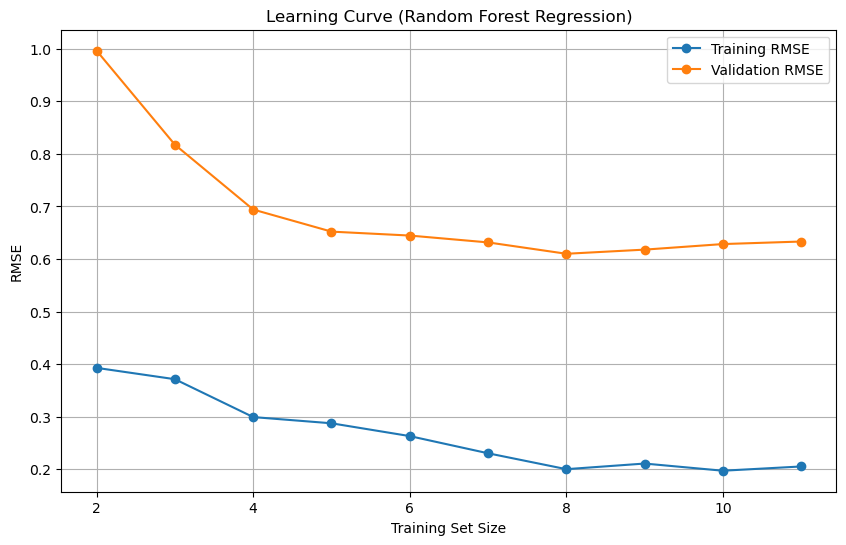

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    estimator=Pipeline,
    X=X,
    y=y,
    cv=5,
    scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.2,1.0, 10),
    shuffle=True,
    random_state=42
)

train_rmse = np.sqrt(-train_scores.mean(axis=1))
val_rmse = np.sqrt(-val_scores.mean(axis=1))

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_rmse, marker='o', label='Training RMSE')
plt.plot(train_sizes, val_rmse, marker='o', label='Validation RMSE')
plt.title("Learning Curve (Random Forest Regression)")
plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.grid(True)
plt.legend()
plt.show()

In [54]:
new_menu = pd.DataFrame([{
    "day_of_week": "Monday",
    "is_lunch": 1,
    "is_dinner": 0,
    "is_weekend": 0,
    "special_dish": 0,
    "num_items": 7,
    "has_desert": 0,
    "is_paneer": 0,
    "is_chicken": 1,
    "spicy_level": 2,
    "variety_score": 3
}])

pred = Pipeline.predict(new_menu)[0]
print("Predicted rating:", round(pred, 2))

Predicted rating: 3.03


In [55]:
pred = Pipeline.predict(new_menu)[0]
pred_rounded = round(pred, 2)

decision = "Eat in mess 👍" if pred > 3 else "Eat outside 👎"

print("Predicted rating:", pred_rounded)
print("Decision:", decision)

Predicted rating: 3.03
Decision: Eat in mess 👍
